# Single trial analysis

In [2]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [7]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.dataTools as dt
from tools.params import colors
import tools.kinematics as kin
import scipy
from joblib import load

from tqdm import tqdm
import tools.viz.utilityTools as vizutils
import tools.decoding as decode

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB



# Compare causal phase methods

In [4]:
SESSIONS = [
    "M061_2025_03_06_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]
session = SESSIONS[0]
td_ = dsp.load_and_preprocess_trials_from_sess(SESSIONS[0], std=0.03, run_pca=False)



##### Loading and preprocessing ######


/root/repos/pyaldata/pyaldata/data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)

##### Dropping unsteady running trials ######
bhv column not found, adding it
otsu immobility threshold: 2.9536
drop_unsteady_running_trials: dropping 78 of 333 trials (23.4%)

##### Calculating perturbation metric ######
bhv field already present, overwriting it
compute_power_in_bhv_concat_td: dropping 11 trial(s) with peak_mean_freq < 2 Hz


In [5]:
# td = dt.add_bhv(td_, bhv_fields=["pos_keypoints"])
td = pyal.restrict_to_interval(
    td_, start_point_name="idx_sol_on", rel_start=-200, rel_end=200,
)
# td, _, _ = kin.rotate_bhv_td(td, validate=False, verbose=False)

# Sinefit: causal phase at perturbation onset

Fit `y(t) = b0 + b1*t + a*cos(2*pi*f*t) + c*sin(2*pi*f*t)` to the last 0.3 s **ending at** onset
(t = 0 at the onset sample, so no post-push data is used). The intercept `b0` and trend `b1*t`
absorb the DC offset and slow drift. Phase at t = 0 is `-atan2(c, a)`
(0 = peak, ±pi = trough). `f` is searched on a small grid around the stride frequency `f0`.

In [ ]:
def sinefit(y, f0, fs=100, f_search=1.0, f_step=0.1):
    """Fit y(t) = b0 + b1*t + a*cos(2*pi*f*t) + c*sin(2*pi*f*t), t = 0 at the last sample.
    Returns phase at t = 0, the best f, the coefficients b, and the window mean."""
    mu = y.mean()
    y = y - mu
    t = (np.arange(len(y)) - (len(y) - 1)) / fs
    best = dict(sse=np.inf)
    all_f = np.arange(f0 - f_search, f0 + f_search + 1e-9, f_step)
    sse_ = []
    for f in all_f:
        A = np.column_stack([np.ones_like(t), t, np.cos(2 * np.pi * f * t), np.sin(2 * np.pi * f * t)])
        b, *_ = np.linalg.lstsq(A, y, rcond=None)
        sse = np.sum((y - A @ b) ** 2)
        sse_.append(sse)
        if sse < best["sse"]:
            best = dict(sse=sse, f=f, b=b)
    sse_ = np.array(sse_)
    phase = -np.arctan2(best["b"][3], best["b"][2])
    return phase, best["f"], best["b"], mu, all_f, sse_

def sinefit_curve(t, f, b, mu):
    """Evaluate the fitted model at times t (seconds, 0 = onset), in raw units."""
    w = 2 * np.pi * f
    return mu + b[0] + b[1] * t + b[2] * np.cos(w * t) + b[3] * np.sin(w * t)

def stride_freq(osc, fs=100):
    """Stride frequency: peak (1-15 Hz) of the mean Welch spectrum across keypoints. osc: (T, n_kp)."""
    f, p = scipy.signal.welch(osc, fs=fs, nperseg=len(osc), nfft=1024, axis=0)
    band = (f >= 1) & (f <= 15)
    return f[band][np.argmax(p.mean(1)[band])]

In [29]:
WINDOW = 30        # samples fitted (0.3 s at 100 Hz)
F0_WIN = 300       # samples used for the stride frequency (3 s)
kp = Params.oscillating_keypoints.index("right_foot")   # bhv_concat holds raw z of these keypoints

trials = td_[td_.trial_name == "trial"]


In [6]:
bc, onset = trials.iloc[0][["bhv_concat", "concat_perturb_time"]]
onset = int(onset)
z = bc[:, kp]                                           # right_foot raw z

f0 = stride_freq(bc[onset - F0_WIN + 1 : onset + 1])
phase, f, b, mu, all_f, sse = sinefit(z[onset - WINDOW + 1 : onset + 1], f0)

t_raw = np.arange(-100, 51) / 100                       # -1 s .. +0.5 s around onset
t_fit = np.arange(-(WINDOW - 1), 51) / 100              # fit window, then forecast
past, future = t_fit <= 0, t_fit >= 0

theta = np.angle(np.exp(1j * (phase + 2 * np.pi * f * t_fit)))   # fitted phase, wrapped to (-pi, pi]
# theta[1:][np.abs(np.diff(theta)) > np.pi] = np.nan               # break the line at each wrap

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7, 5))

ax1.plot(t_raw, z[onset - 100 : onset + 51], color="0.6", label="right_foot z")
ax1.plot(t_fit[past], sinefit_curve(t_fit[past], f, b, mu), lw=2, color="C0", label="fit")
ax1.plot(t_fit[future], sinefit_curve(t_fit[future], f, b, mu), lw=2, ls="--", color="C0",
         label="pred")
ax1.set_ylabel("z")
ax1.set_title(f"f = {f:.1f} Hz, onset phase = {phase:.2f} rad")
ax1.legend()

ax2.plot(t_fit[past], theta[past], lw=2, color="C0")
ax2.plot(t_fit[future], theta[future], lw=2, ls="--", color="C0")
ax2.plot(0, phase, "o", color="k")                                # the onset phase
ax2.set_yticks([-np.pi, 0, np.pi], ["-pi", "0", "pi"])
ax2.set_ylabel("phase")
ax2.set_xlabel("time from onset (s)")

for ax in (ax1, ax2):
    ax.axvline(0, color="k", lw=0.8)
fig.tight_layout()

NameError: name 'trials' is not defined

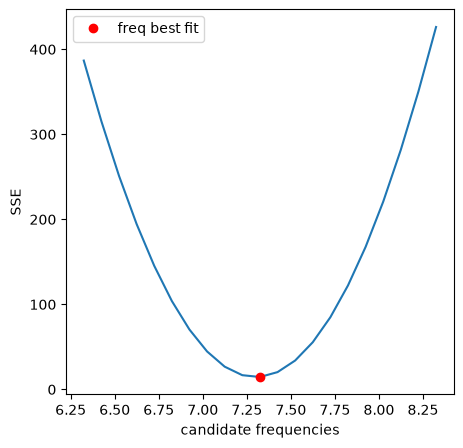

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(all_f, sse)
ax.plot(all_f[sse.argmin()], sse.min(), 'ro', label='freq best fit')
ax.set(ylabel='SSE', xlabel='candidate frequencies')
ax.legend()

# Agreement with Hilber

In [102]:
errs = []
kp = Params.oscillating_keypoints.index("right_foot")   # bhv_concat holds raw z of these keypoints

for bc, onset in trials[["bhv_concat", "concat_perturb_time"]].itertuples(index=False):
    z = bc[:, kp]                                           # right_foot raw z
    f0 = stride_freq(bc[onset - F0_WIN + 1 : onset + 1])
    phase, f, b, mu, all_f, sse = sinefit(z[onset - WINDOW + 1 : onset + 1], f0)

    bp_signal = dsp.sos_bandpass_filter(
        z[onset - F0_WIN :],
        fs=100,
        freqs=(f0-1, f0+1)
    )
    _, phase_h = dsp.compute_hilbert_power(bp_signal)

    errs.append(np.angle(np.exp(1j * (phase - phase_h[300]))))

errs = np.array(errs)

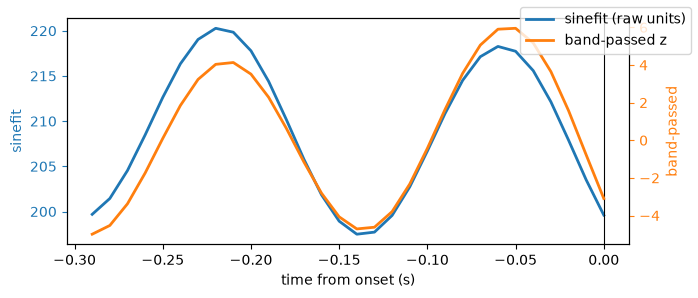

In [112]:
t_fit = np.arange(-(WINDOW - 1), 51) / 100
past = t_fit <= 0
seg_on = F0_WIN                   # onset's index inside bp_signal (segment starts at onset - F0_WIN + 1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_fit[past], sinefit_curve(t_fit[past], f, b, mu), lw=2, color="C0", label="sinefit (raw units)")
ax.set_ylabel("sinefit", color="C0")
ax.tick_params(axis="y", colors="C0")

ax2 = ax.twinx()
ax2.plot(t_fit[past], bp_signal[seg_on - WINDOW + 1 : seg_on + 1], lw=2, color="C1", label="band-passed z")
ax2.set_ylabel("band-passed", color="C1")
ax2.tick_params(axis="y", colors="C1")

ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("time from onset (s)")
fig.legend()
fig.tight_layout()

Text(0.5, 1.0, 'sinefit - Hilbert = +12°')

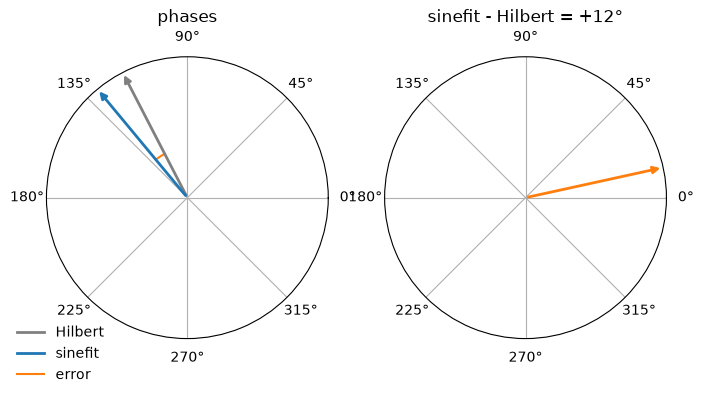

In [113]:
phi_h = phase_h[300]
phi_s = phase
err = np.angle(np.exp(1j * (phi_s - phi_h)))           # sinefit - Hilbert, wrapped to (-pi, pi]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), subplot_kw=dict(projection="polar"))
for ax in (ax1, ax2):
    ax.set_ylim(0, 1)                                  # fix the radius first, or the arrows get clipped
    ax.set_yticks([])

# left: both phases and the arc between them
for ang, col, lab in [(phi_h, "0.5", "Hilbert"), (phi_s, "C0", "sinefit")]:
    ax1.annotate("", xy=(ang, 1), xytext=(0, 0), annotation_clip=False,
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=2))
    ax1.plot([], [], color=col, lw=2, label=lab)       # legend handle
arc = phi_h + np.linspace(0, err, 50)                  # arc from Hilbert to sinefit
ax1.plot(arc, np.full_like(arc, 0.35), color="C1", lw=1.5, label="error")
ax1.set_title("phases")
ax1.legend(loc="lower left", bbox_to_anchor=(-0.15, -0.2), frameon=False)

# right: the difference as its own arrow, 0 deg = perfect agreement
ax2.annotate("", xy=(err, 1), xytext=(0, 0), annotation_clip=False,
             arrowprops=dict(arrowstyle="-|>", color="C1", lw=2))
ax2.set_title(f"sinefit - Hilbert = {np.rad2deg(err):+.0f}°")

Text(0.5, 1.0, 'sinefit - Hilbert, n = 244\nR = 0.92, offset = +6.6°')

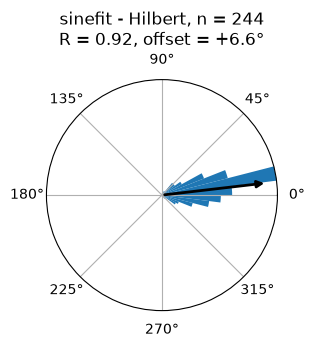

In [104]:
m = np.mean(np.exp(1j * errs))                 # mean arrow
R, offset = np.abs(m), np.angle(m)

fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(projection="polar")
ax.set_ylim(0, 1)
ax.set_yticks([])

counts, edges = np.histogram(errs, bins=50, range=(-np.pi, np.pi))
ax.bar(edges[:-1], counts / counts.max(), width=np.diff(edges), align="edge",
       color="C0")          # tallest bin = 1
ax.annotate("", xy=(offset, R), xytext=(0, 0), annotation_clip=False,
            arrowprops=dict(arrowstyle="-|>", color="k", lw=2))   # length R, direction = offset
ax.set_title(f"sinefit - Hilbert, n = {len(errs)}\n"
             f"R = {R:.2f}, offset = {np.rad2deg(offset):+.1f}°")

# Agreement with Hilbert, all keypoints

Same comparison as above (sinefit at onset vs full-trace Hilbert at onset), for each of the 12
oscillating keypoints in `bhv_concat` (raw z). f0 is shared across keypoints (one stride frequency per trial).

In [114]:
import pandas as pd

rows = []
for kp_name in Params.oscillating_keypoints:
    kp_i = Params.oscillating_keypoints.index(kp_name)
    errs_kp = []
    for bc, onset in trials[["bhv_concat", "concat_perturb_time"]].itertuples(index=False):
        onset = int(onset)
        z = bc[:, kp_i]
        f0 = stride_freq(bc[onset - F0_WIN + 1 : onset + 1])
        phi_s = sinefit(z[onset - WINDOW + 1 : onset + 1], f0)[0]

        seg = z[onset - F0_WIN :]                                 # onset is at index F0_WIN
        bp = dsp.sos_bandpass_filter(seg - seg.mean(), fs=100, freqs=(f0 - 1, f0 + 1))
        _, ph_h = dsp.compute_hilbert_power(bp)

        errs_kp.append(np.angle(np.exp(1j * (phi_s - ph_h[F0_WIN]))))
    m = np.mean(np.exp(1j * np.array(errs_kp)))
    rows.append(dict(keypoint=kp_name, R=np.abs(m), offset_deg=np.rad2deg(np.angle(m)), n=len(errs_kp)))

agree = pd.DataFrame(rows).sort_values("R", ascending=False).reset_index(drop=True)
agree.round(3)

,keypoint,R,offset_deg,n
0,left_ankle,0.931,9.314,244
1,left_paw,0.928,6.540,244
2,left_wrist,0.926,6.162,244
3,left_foot,0.926,8.581,244
4,left_knee,0.924,8.785,244
5,right_elbow,0.918,5.846,244
6,right_foot,0.917,6.639,244
7,right_ankle,0.917,6.486,244
8,right_paw,0.917,7.379,244
9,right_wrist,0.917,7.525,244


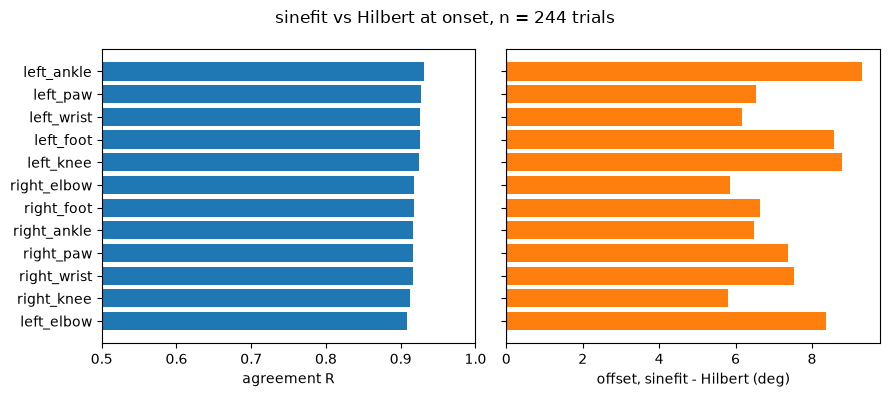

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
y = np.arange(len(agree))

ax1.barh(y, agree.R, color="C0")
ax1.set_yticks(y, agree.keypoint)
ax1.invert_yaxis()                                        # best at the top
ax1.set_xlim(0.5, 1)
ax1.set_xlabel("agreement R")

ax2.barh(y, agree.offset_deg, color="C1")
ax2.axvline(0, color="k", lw=0.8)
ax2.set_xlabel("offset, sinefit - Hilbert (deg)")

fig.suptitle(f"sinefit vs Hilbert at onset, n = {agree.n.iloc[0]} trials")
fig.tight_layout()

In [7]:
F0_WIN

NameError: name 'F0_WIN' is not defined

# Agreement with Hilbert: all keypoints x (x, y, z) x sessions

Same comparison as above (sinefit at onset vs full-trace Hilbert at onset), for the 19 position keypoints in
x, y and z, across the canonical 11 sessions (`cu.load_session`). Uses the trial row only (no `bhv_concat`,
which holds limb z alone): 2 s before onset instead of 3 s, so f0 comes from 2 s. The first run computes and
caches a CSV on the interim drive; later runs just load it. The summary averages sessions within each animal
first (sessions are nested in animals), then takes the median over the 7 animals, and repeats the keypoint
choice leave-one-animal-out.

In [3]:
import pandas as pd
sys.path.append("../../across-sessions")
import common_utils as cu

OUT = Params.ACROSS_SESSION_RESULTS_DIR / "phase-estimation-benchmark" / "data" / "notebook_sinefit_vs_hilbert_onset.csv"
KEYPOINTS = Params.pos_keypoints            # 19 position keypoints, each (T, 3) = x, y, z
DIMS = ["x", "y", "z"]
F0_WIN_ROW = 200                            # a trial row only holds 2 s before onset (vs 3 s in bhv_concat)


def session_agreement(td):
    """R and offset of sinefit vs full-trace Hilbert at onset, for every keypoint x dim,
    using only the trial row itself (2 s before onset, the rest after)."""
    trials = td[td.trial_name == "trial"]
    errs = np.full((len(trials), len(KEYPOINTS), 3), np.nan)
    for i, (_, row) in enumerate(trials.iterrows()):
        onset = int(row.idx_sol_on)
        osc = np.column_stack([row[kp][:, 2] for kp in Params.oscillating_keypoints])   # 12 limb z
        f0 = stride_freq(osc[onset - F0_WIN_ROW + 1 : onset + 1])                       # data <= onset
        for k, kp in enumerate(KEYPOINTS):
            for d in range(3):
                z = row[kp][:, d]
                if not np.isfinite(z).all():
                    continue
                phi_s = sinefit(z[onset - WINDOW + 1 : onset + 1], f0)[0]
                bp = dsp.sos_bandpass_filter(z - z.mean(), fs=100, freqs=(f0 - 1, f0 + 1))
                _, ph_h = dsp.compute_hilbert_power(bp)
                errs[i, k, d] = phi_s - ph_h[onset]

    m = np.nanmean(np.exp(1j * errs), axis=0)                      # mean arrow, (19, 3)
    return pd.DataFrame(dict(
        keypoint=np.repeat(KEYPOINTS, 3), dim=np.tile(DIMS, len(KEYPOINTS)),
        R=np.abs(m).ravel(), offset_deg=np.rad2deg(np.angle(m)).ravel(),
        n=np.isfinite(errs).sum(0).ravel(),
    ))


if OUT.exists():                                                   # computed once, then just loaded
    res = pd.read_csv(OUT)
else:
    res = []
    for s in cu.ALL_SESSIONS:
        r = session_agreement(cu.load_session(s))
        r.insert(0, "session", s)
        r.insert(1, "animal", s[:4])
        res.append(r)
        print(s, "done")
    res = pd.concat(res, ignore_index=True)
    res.to_csv(OUT, index=False)
res


,session,animal,keypoint,dim,R,offset_deg,n
0,M061_2025_03_04_10_00,M061,left_ankle,x,0.912271,4.964869,203
1,M061_2025_03_04_10_00,M061,left_ankle,y,0.631998,4.287770,203
2,M061_2025_03_04_10_00,M061,left_ankle,z,0.904949,4.867488,203
3,M061_2025_03_04_10_00,M061,left_elbow,x,0.804224,11.513413,203
4,M061_2025_03_04_10_00,M061,left_elbow,y,0.891038,8.809337,203
...,...,...,...,...,...,...,...
622,M106_2026_02_25_15_00,M106,tail_middle,y,0.415318,3.728092,212
623,M106_2026_02_25_15_00,M106,tail_middle,z,0.674165,-2.160834,212
624,M106_2026_02_25_15_00,M106,tail_tip,x,0.713312,-0.738580,212
625,M106_2026_02_25_15_00,M106,tail_tip,y,0.382536,4.623779,212


/tmp/ipykernel_374753/1581974122.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  order = med_R.max(1).sort_values(ascending=False).index                 # best keypoints at the top


held-out R: median 0.930 [0.921, 0.944], 7 animals
pick
right_foot z    7


,held_out,pick,R_held_out
0,M061,right_foot z,0.932591
1,M062,right_foot z,0.927640
2,M063,right_foot z,0.921185
3,M078,right_foot z,0.943860
4,M086,right_foot z,0.928332
5,M103,right_foot z,0.943608
6,M106,right_foot z,0.929636


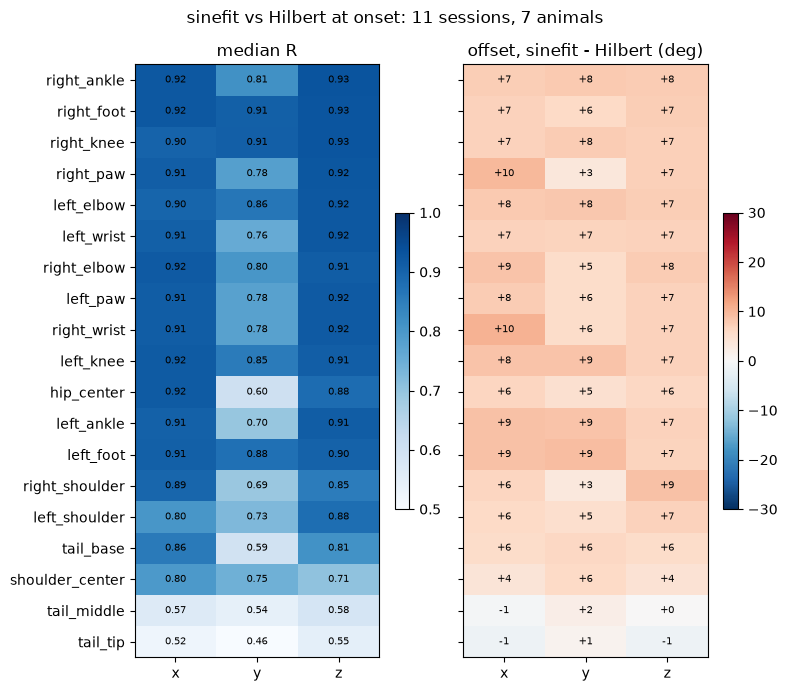

In [ ]:
# per keypoint x dim: median across sessions (sessions are nested in animals, so animal-level below)
per_animal = res.groupby(["animal", "keypoint", "dim"])[["R", "offset_deg"]].mean().reset_index()
med_R = per_animal.pivot_table(index="keypoint", columns="dim", values="R", aggfunc="median")
med_off = per_animal.pivot_table(index="keypoint", columns="dim", values="offset_deg", aggfunc="median")
order = med_R.max(1).sort_values(ascending=False).index                 # best keypoints at the top
med_R, med_off = med_R.loc[order], med_off.loc[order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7), sharey=True)
im1 = ax1.imshow(med_R, cmap="Blues", vmin=0.5, vmax=1, aspect="auto")
im2 = ax2.imshow(med_off, cmap="RdBu_r", vmin=-30, vmax=30, aspect="auto")
for ax, tab, fmt in [(ax1, med_R, "{:.2f}"), (ax2, med_off, "{:+.0f}")]:
    ax.set_xticks(range(3), tab.columns)
    for (r, c), v in np.ndenumerate(tab.values):
        ax.text(c, r, fmt.format(v), ha="center", va="center", fontsize=7, color="k" if ax is ax1 else "k")
ax1.set_yticks(range(len(order)), order)
ax1.set_title("median R")
ax2.set_title("offset, sinefit - Hilbert (deg)")
fig.colorbar(im1, ax=ax1, shrink=0.5); fig.colorbar(im2, ax=ax2, shrink=0.5)
fig.suptitle(f"sinefit vs Hilbert at onset: {res.session.nunique()} sessions, {res.animal.nunique()} animals")
fig.tight_layout()

# held-out pick: choose the best keypoint-dim on 6 animals, score it on the 7th
R_tab = per_animal.pivot_table(index="animal", columns=["keypoint", "dim"], values="R")
folds = []
for a in R_tab.index:
    pick = R_tab.drop(index=a).mean().idxmax()
    folds.append(dict(held_out=a, pick=" ".join(pick), R_held_out=R_tab.loc[a, pick]))
folds = pd.DataFrame(folds)
print(f"held-out R: median {folds.R_held_out.median():.3f} "
      f"[{folds.R_held_out.min():.3f}, {folds.R_held_out.max():.3f}], 7 animals")
print(folds.pick.value_counts().to_string())
folds


# Check loading again

In [4]:
SESSIONS = [
    "M061_2025_03_06_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    # "M106_2026_02_25_15_00",  
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]
session = SESSIONS[0]
td_ = dsp.load_and_preprocess_trials_from_sess(SESSIONS[0], std=0.03, run_pca=False)



##### Loading and preprocessing ######


/root/repos/pyaldata/pyaldata/data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/root/repos/pyaldata/pyaldata/utils.py:164: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)

##### Dropping unsteady running trials ######
bhv column not found, adding it
otsu immobility threshold: 2.9536
drop_unsteady_running_trials: dropping 78 of 333 trials (23.4%)

##### Calculating perturbation metric ######
bhv field already present, overwriting it
compute_power_in_bhv_concat_td: dropping 11 trial(s) with peak_mean_freq < 2 Hz


In [45]:
# td = dt.add_bhv(td_, bhv_fields=["pos_keypoints"])
td = dsp.drop_unperturbed_or_stopped_trials(td_)
td = pyal.restrict_to_interval(
    td, start_point_name="idx_sol_on", rel_start=-200, rel_end=200,
)
# td, _, _ = kin.rotate_bhv_td(td, validate=False, verbose=False)

  drop_unperturbed_trials: dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)


In [8]:
RUN_TAG = "lpt_rauto_k10"   # <-- the run-tag folder to visualize
RUN_DIR = Params.ACROSS_SESSION_RESULTS_DIR / "kinematic-dpca-noisefloor" / RUN_TAG


sess = 'M061_2025_03_06_14_00'
b = load(RUN_DIR / f"{sess}_fit.joblib")
m, X, cond_values, trialX = b["dpca"], b["X_psth"], b["cond_values"], b["trialX"]
feat = np.load(Params.ACROSS_SESSION_RESULTS_DIR / "cache" / f"{sess}.npz",
               allow_pickle=True)["labels"]
keys = ['t', 'lt', 'pt', 'lpt']
Zc = m.transform(X)                                       # key -> (n_comp, n_level, n_angle, n_time)
t = np.arange(X.shape[-1]) / 100 - 0.5   


In [10]:
def drop_nan_trials(trialX):
    """Drop padded trial slots (all-NaN across features/time) from trialX.

    trialX: (n_trial, n_features, n_level, n_angle, n_time)
    Returns a boolean valid-trial mask of shape (n_trial, n_level, n_angle)
    and, if you want a flat list per condition, a dict of arrays.
    """
    valid = ~np.isnan(trialX).all(axis=(1, 4))  # (n_trial, n_level, n_angle)
    return valid

In [11]:
mask = drop_nan_trials(trialX)
trial_i, level_i, angle_i = np.where(mask)
trials = trialX[trial_i, :, level_i, angle_i, :]   # (n_valid, n_features, n_time)
trials.shape


(208, 57, 200)

In [17]:
marg = 't'

# projects directly on the real feature axis (trials.shape[1]) -- no reshape needed
proj = np.tensordot(m.P[marg], trials, axes=([0], [1]))   # (n_comp, n_valid_trials, n_time)
proj = proj.transpose((1, 0, 2))

In [35]:
var_in_trials = np.var(proj, axis=-1)
var_in_trials.shape

(208, 10)

In [ ]:
np.var(proj[0, ])

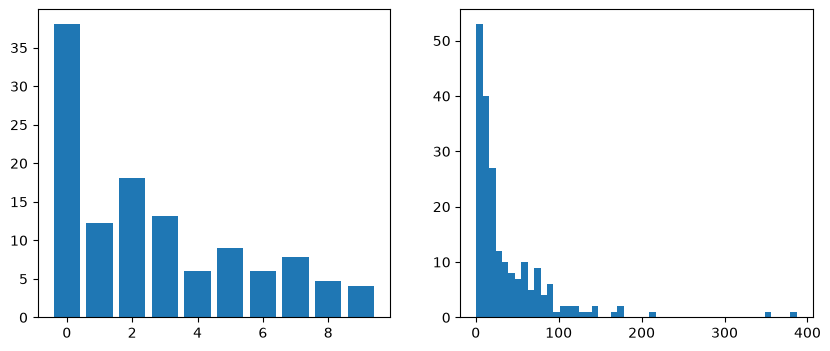

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(range(10), var_in_trials.mean(0))
ax[1].hist(var_in_trials[:, 0], bins=50)
plt.show()

# Trials with low variance on the condition-independent component

Trials whose projection onto `marg` component `COMP` has variance over time below `VAR_THRESH`.

In [38]:
import pandas as pd

VAR_THRESH = 10    # variance threshold
COMP = 0           # which `marg` component the variance is taken on (the histogram above is component 0)

low = var_in_trials[:, COMP] < VAR_THRESH
levels, angles = cond_values
lev_of, ang_of = np.array(levels)[level_i], np.array(angles)[angle_i]   # condition of each valid trial
print(f"{low.sum()} / {len(low)} trials with var < {VAR_THRESH} on '{marg}' component {COMP}")

# where do they fall: level x angle counts, low-variance trials vs all trials
pd.concat({"var < thresh": pd.crosstab(lev_of[low], ang_of[low]),
           "all": pd.crosstab(lev_of, ang_of)}, names=["", "level"]).rename_axis(columns="angle")

64 / 208 trials with var < 10 on 't' component 0


angle               30   90   150  210  270  330
             level                              
var < thresh 0        0    8    2    3    9    2
             1       10    8    9    5    5    3
all          0       16   14   11   22   11   24
             1       25   20   23   14    9   19

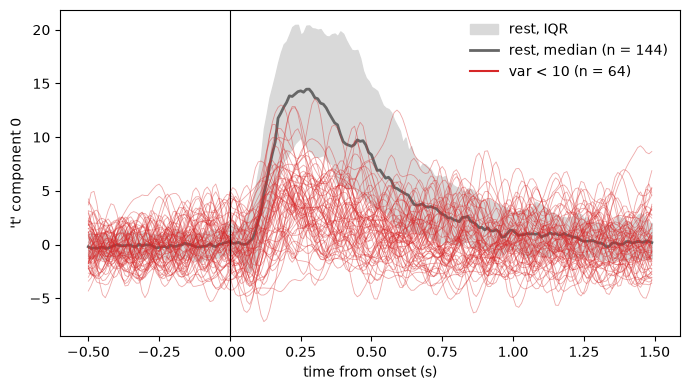

In [39]:
# low-variance trials overlaid on the rest (median + IQR)
hi = proj[~low, COMP]

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(t, *np.percentile(hi, [25, 75], axis=0), color="0.85", label="rest, IQR")
ax.plot(t, np.median(hi, axis=0), color="0.4", lw=2, label=f"rest, median (n = {len(hi)})")
ax.plot(t, proj[low, COMP].T, color="C3", lw=0.6, alpha=0.4)
ax.plot([], [], color="C3", label=f"var < {VAR_THRESH} (n = {low.sum()})")    # legend handle
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="time from onset (s)", ylabel=f"'{marg}' component {COMP}")
ax.legend(frameon=False)
fig.tight_layout()

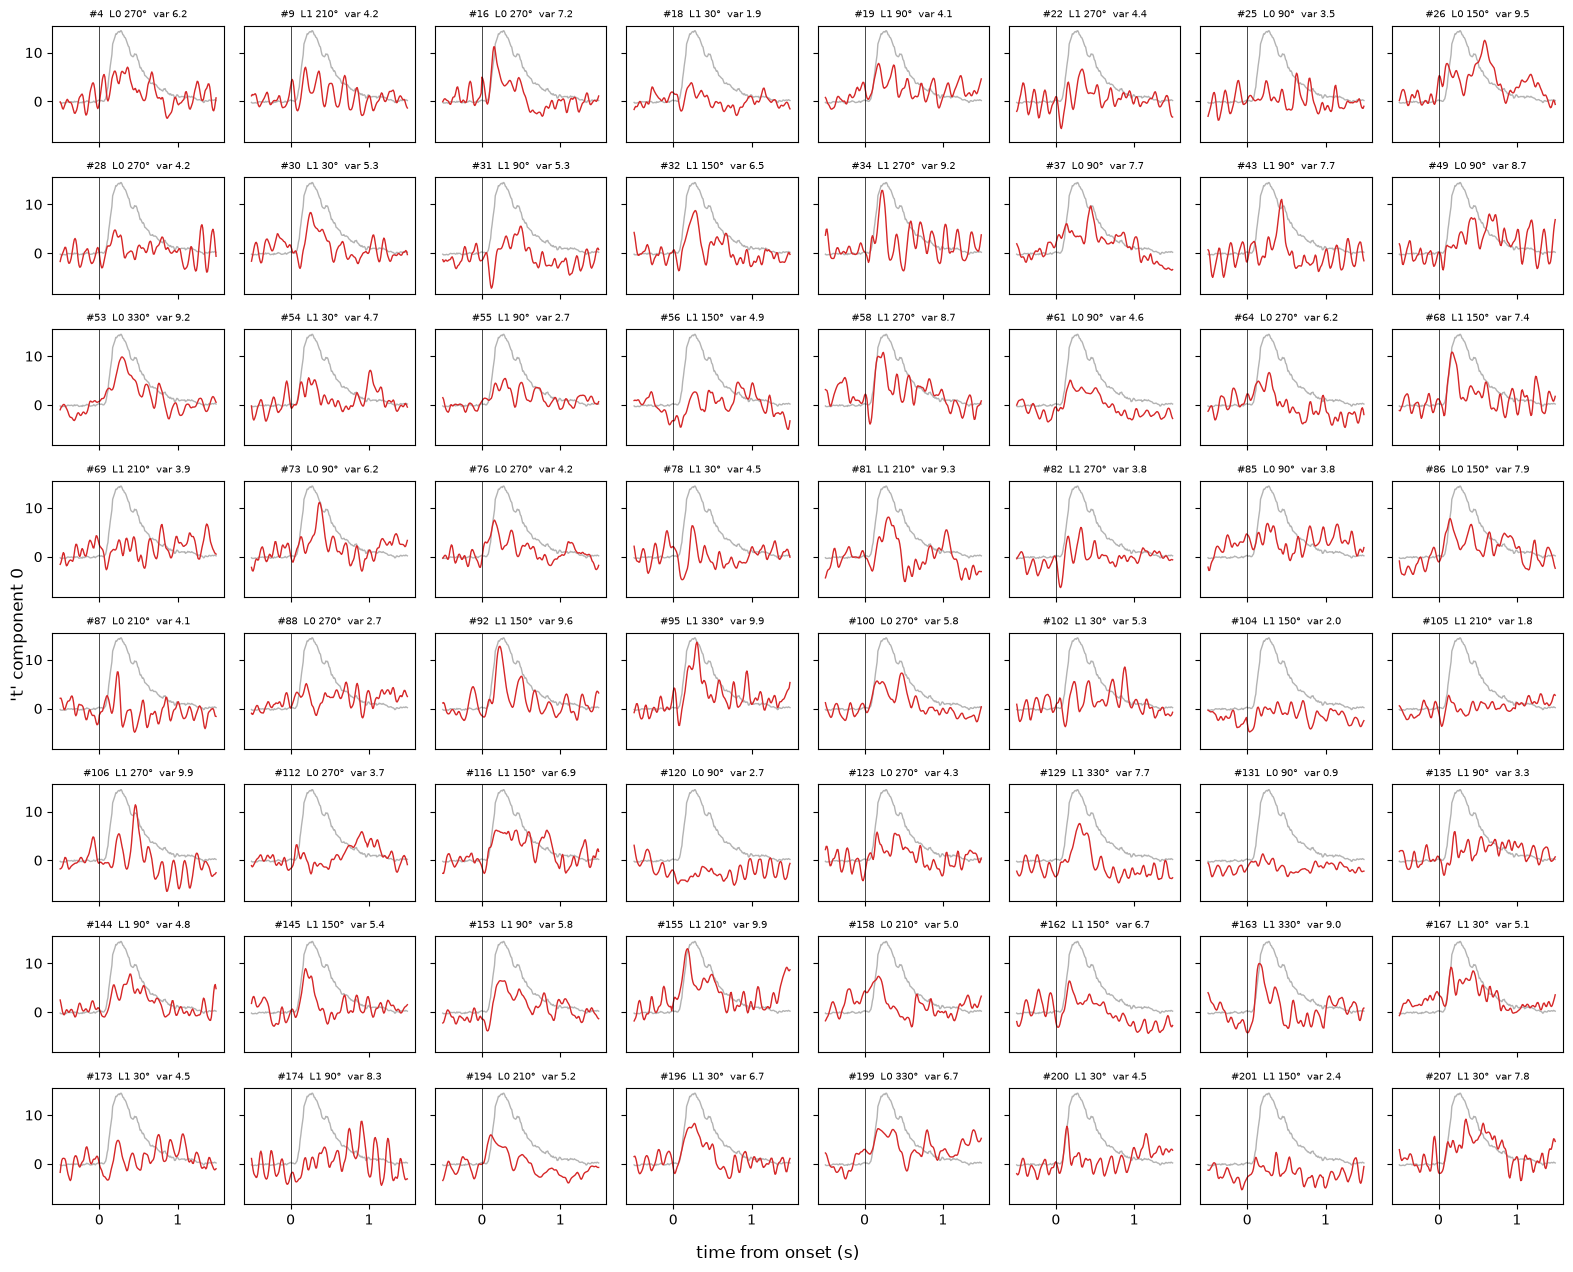

In [40]:
# every low-variance trial on its own, against the median of the rest (grey)
idx = np.flatnonzero(low)
ncol = 8
nrow = int(np.ceil(len(idx) / ncol))
ref = np.median(proj[~low, COMP], axis=0)

fig, axs = plt.subplots(nrow, ncol, figsize=(2 * ncol, 1.6 * nrow), sharex=True, sharey=True,
                        squeeze=False)
for ax, i in zip(axs.flat, idx):
    ax.plot(t, ref, color="0.7", lw=1)
    ax.plot(t, proj[i, COMP], color="C3", lw=1)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"#{i}  L{lev_of[i]} {ang_of[i]}°  var {var_in_trials[i, COMP]:.1f}", fontsize=7)
for ax in axs.flat[len(idx):]:
    ax.axis("off")
fig.supxlabel("time from onset (s)")
fig.supylabel(f"'{marg}' component {COMP}")
fig.tight_layout()

# Cosinor fit

In [71]:
# Response size per trial: post-onset variance summed over the 10 't' components, in RECORDING order.
# `proj` comes from trialX, which is ordered by condition cell (slot x level x angle), not by recording
# order like `td`. `order[j]` is the recording-order position of dPCA trial j.
import scipy.stats as stats
import tools.dimensionality as dim

POST = 50            # first post-onset sample (t = 0 s; trialX starts at -0.5 s)
KP = "right_foot"    # whose phase_at_perturb to use

fit = load(RUN_DIR / f"{sess}_fit.joblib")                       # reloaded: `b` is reused by the sinefit cells
codes = np.asarray(fit["codes"])                                 # the dPCA trials, recording order
conds = dim.conditions_from_codes(codes, fit["config"]["factors"])
slots = [np.unique(c, return_inverse=True)[1] for c in conds]
by_cell = {}
for k, cell in enumerate(zip(*slots)):
    by_cell.setdefault(cell, []).append(k)                       # same grouping as the tensor builder
order = np.array([by_cell[(l, a)][s] for s, l, a in zip(trial_i, level_i, angle_i)])

var_post = np.var(proj[:, :, POST:], axis=-1).sum(axis=1)        # (n_trials,) summed over components
y = np.empty(len(order))
y[order] = var_post
y = np.log(y)                                                    # raw variance is very skewed

x = np.stack(td.phase_at_perturb.values)[:, Params.oscillating_keypoints.index(KP)]
assert len(x) == len(y), "td must hold the same trials as the dPCA fit (dropped set, trial rows only)"
print(f"{len(y)} trials, {proj.shape[1]} components, samples {POST}-{proj.shape[-1]} (t = {t[POST]:.2f} to {t[-1]:.2f} s)")

208 trials, 10 components, samples 50-200 (t = 0.00 to 1.49 s)


In [72]:
# Cosinor fit: log var = b0 + b1 cos(phase) + b2 sin(phase)
#   preferred phase = atan2(b2, b1): the phase at the push where the response is largest
#   amplitude       = hypot(b1, b2): on the log scale, so exp(amp) is the peak / mean ratio
def cosinor(x, y):
    D = np.column_stack([np.ones_like(x), np.cos(x), np.sin(x)])
    beta, *_ = np.linalg.lstsq(D, y, rcond=None)
    r2 = 1 - np.sum((y - D @ beta) ** 2) / np.sum((y - y.mean()) ** 2)
    return beta, r2

beta, r2 = cosinor(x, y)
b0, b1, b2 = beta
pref, amp = np.arctan2(b2, b1), np.hypot(b1, b2)

# in-sample F test
n = len(y)
f_stat = (r2 / 2) / ((1 - r2) / (n - 3))
p_f = stats.f.sf(f_stat, 2, n - 3)

# permutation test: shuffle phase across trials (makes no normality assumption)
rng = np.random.default_rng(0)
null = np.array([cosinor(rng.permutation(x), y)[1] for _ in range(5000)])
p_perm = (1 + np.sum(null >= r2)) / (1 + len(null))

# held-out R^2: 5-fold CV by trial, 20 repeats. ~0 or negative = phase predicts nothing out of sample
r2_cv = []
for _ in range(20):
    folds = np.array_split(rng.permutation(n), 5)
    pred = np.empty(n)
    for f in folds:
        tr = np.setdiff1d(np.arange(n), f)
        bt, _ = cosinor(x[tr], y[tr])
        pred[f] = bt[0] + bt[1] * np.cos(x[f]) + bt[2] * np.sin(x[f])
    r2_cv.append(1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2))

print(f"preferred phase = {pref:+.2f} rad ({np.rad2deg(pref):+.0f} deg), "
      f"peak/mean = x{np.exp(amp):.2f}")
print(f"R^2 = {r2:.3f}, F(2,{n - 3}) = {f_stat:.2f}, p = {p_f:.4f}, permutation p = {p_perm:.4f}")
print(f"held-out R^2 = {np.median(r2_cv):+.3f} [{np.min(r2_cv):+.3f}, {np.max(r2_cv):+.3f}] over 20 CV repeats")

preferred phase = -2.88 rad (-165 deg), peak/mean = x1.09
R^2 = 0.010, F(2,205) = 1.06, p = 0.3500, permutation p = 0.3573
held-out R^2 = -0.028 [-0.059, -0.002] over 20 CV repeats


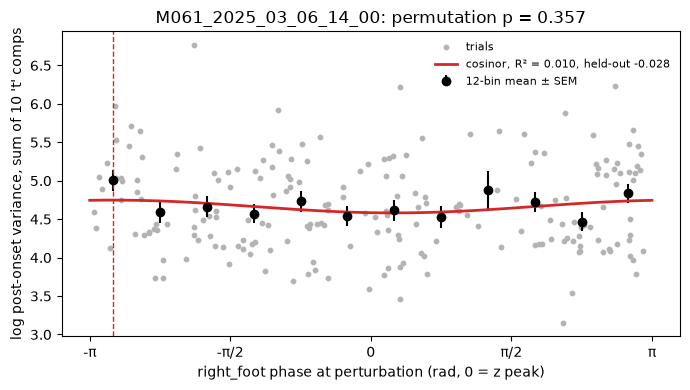

In [73]:
# log variance vs phase at the push: trials, 12-bin means (+- SEM), and the fitted cosinor
grid = np.linspace(-np.pi, np.pi, 200)
edges = np.linspace(-np.pi, np.pi, 13)
centers = (edges[:-1] + edges[1:]) / 2
bin_of = np.clip(np.digitize(x, edges) - 1, 0, 11)
bin_mean = np.array([y[bin_of == k].mean() for k in range(12)])
bin_sem = np.array([y[bin_of == k].std(ddof=1) / np.sqrt((bin_of == k).sum()) for k in range(12)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=10, color="0.7", label="trials")
ax.errorbar(centers, bin_mean, bin_sem, fmt="o", color="k", label="12-bin mean ± SEM")
ax.plot(grid, b0 + b1 * np.cos(grid) + b2 * np.sin(grid), color="C3", lw=2,
        label=f"cosinor, R² = {r2:.3f}, held-out {np.median(r2_cv):+.3f}")
ax.axvline(pref, color="C3", ls="--", lw=1)
ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi], ["-π", "-π/2", "0", "π/2", "π"])
ax.set(xlabel=f"{KP} phase at perturbation (rad, 0 = z peak)",
       ylabel=f"log post-onset variance, sum of {proj.shape[1]} '{marg}' comps")
ax.set_title(f"{sess}: permutation p = {p_perm:.3f}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

# dPCA projections as td columns

Same reordering as the cosinor cell above, wrapped as a function and applied to every marginalization.

In [ ]:
def add_dpca_projections(td, fit_path, prefix="dpca_"):
    """Add each trial's projection onto every dPCA marginalization as a td column.

    trialX is laid out by condition cell (padded slot x level x angle), not in recording order.
    fit["codes"] IS in recording order, so regrouping it exactly as dim.build_unbalanced_trial_tensor
    does gives each trial its cell and its slot within that cell. Indexing trialX with those picks
    every real trial once, in recording order; the NaN padding slots are never picked.

    Adds f"{prefix}{key}" per marginalization key: (n_time, n_comp) per trial, on the dPCA time axis
    (the fit's -0.5 to 1.5 s window at 100 Hz), not the td's own time axis.
    """
    fit = load(fit_path)
    m, codes = fit["dpca"], np.asarray(fit["codes"])
    td_codes = np.array([int(np.ravel(v)[0]) for v in td.values_Sol_direction])
    assert np.array_equal(td_codes, codes), "td must hold the dPCA trials (dropped set), in the same order"

    conds = dim.conditions_from_codes(codes, fit["config"]["factors"])
    slots = [np.unique(c, return_inverse=True)[1] for c in conds]   # cell index along each factor, per trial
    rank, count = np.zeros(len(codes), int), {}                     # slot of each trial within its cell
    for k, cell in enumerate(zip(*slots)):
        rank[k] = count.get(cell, 0)
        count[cell] = rank[k] + 1
    trials = fit["trialX"][(rank, slice(None), *slots, slice(None))]  # (n_trials, n_features, n_time)
    assert not np.isnan(trials).all(axis=(1, 2)).any(), "picked a padding slot"

    td = td.copy()
    for key, P in m.P.items():                                      # P[key]: (n_features, n_comp)
        td[f"{prefix}{key}"] = list(np.einsum("fc,nft->ntc", P, trials))
    return td


td_dpca = add_dpca_projections(dsp.drop_unperturbed_or_stopped_trials(td_), RUN_DIR / f"{sess}_fit.joblib")
[c for c in td_dpca.columns if c.startswith("dpca_")], td_dpca.dpca_t.iloc[0].shape